# Cross-Validation Strategies in Machine Learning

> **A Premium Educational Resource | MIT ML Curriculum | Senior ML Engineer Edition**

---

## 📌 Notebook Objective

This notebook teaches you **Cross-Validation** — one of the most important and widely misunderstood concepts in Machine Learning — from complete beginner intuition all the way to production-level mastery.

Whether you are a **first-year B.Tech student** encountering Machine Learning for the very first time, a **non-IT professional** curious about how AI systems are built and evaluated, or a **working ML engineer** preparing for a FAANG technical interview, this notebook is designed with you specifically in mind.

Every concept is introduced gently and then deepened gradually. Nothing is assumed. Every technical term is defined the moment it appears.

---

## 🎯 Learning Outcomes

By the end of this notebook, you will be able to:

1. Explain **why** cross-validation exists and what fundamental problem it solves.
2. Clearly distinguish between **training data**, **validation data**, and **test data**.
3. Implement **manual K-Fold Cross-Validation** from scratch using only NumPy — no shortcuts.
4. Use **Scikit-learn's built-in** cross-validation tools the way professional engineers do.
5. Compare and choose between **K-Fold**, **Stratified K-Fold**, and **Leave-One-Out** strategies.
6. Recognize and avoid the most common cross-validation mistakes made in industry.
7. Confidently answer cross-validation questions in **technical placements and FAANG interviews**.

---

## 📋 Prerequisites

You only need:
- A basic understanding of what a Python variable is
- Familiarity with lists or arrays (e.g., `[1, 2, 3]`)
- (Optional but helpful) Basic awareness of what a Pandas DataFrame looks like

**No prior Machine Learning knowledge is required.** Every term — fold, validation, overfitting, bias, variance — will be clearly defined the first time it appears.

---

## 🌸 Dataset: Iris Flower Dataset

We will use the **Iris dataset** throughout this notebook — one of the most famous and carefully studied real-world datasets in the history of Machine Learning.

**What is it?**  
The Iris dataset contains physical measurements of **150 real iris flowers**, recorded by botanist Edgar Anderson in 1936. Each flower belongs to one of three species:
- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

For each flower, four measurements (**features**) were recorded:

| Feature | What it measures |
|---------|------------------|
| Sepal Length (cm) | Length of the outer leaf-like part of the flower |
| Sepal Width (cm) | Width of the same outer part |
| Petal Length (cm) | Length of the inner colourful petal |
| Petal Width (cm) | Width of the inner petal |

> 🔖 **What is a Feature?** A feature is one measurable property of a data point. Think of it as one column in a spreadsheet. The model uses features to make predictions.

**Why the Iris dataset?**  
It is small (150 rows), completely real, perfectly clean, and ideally suited for demonstrating evaluation strategies without getting lost in complex data engineering.

📦 **Dataset also available on Kaggle:** [https://www.kaggle.com/datasets/uciml/iris](https://www.kaggle.com/datasets/uciml/iris)

---

## ❓ Why Does Cross-Validation Exist? The Core Problem

### 🏫 Analogy: The Unfair Exam

Imagine a school teacher who gives students 100 practice questions to study. Then, on exam day, the teacher tests them on those **exact same 100 questions**. Every student scores 100%. Does that mean they have mastered the subject?

**No.** They memorized the answers. They have not actually understood the underlying concepts. Give them a slightly different question on the same topic, and they will fail.

A Machine Learning model faces the same trap. If we:
1. Train the model on some data, AND
2. Measure how accurate it is on that **same data**

...the accuracy score looks brilliant. But the model has simply memorized the training examples. It may completely fail when deployed on real, new data.

This is called **overfitting** — the model fits the training data too closely and loses the ability to generalize.

> 🔖 **What is Generalization?** Generalization is a model's ability to perform correctly on data it has never seen before. A model that generalizes well is one that has truly learned the patterns, not just the memorized answers.

### 🎲 The Single Train-Test Split Problem

The simplest fix is to split data: train on 80%, test on the remaining 20%. But this creates a new problem — the test result depends entirely on which 20% you happened to pick.

**Micro Example:**
```
Run 1: Lucky split  → easy test samples  → Accuracy = 98%  ✅ (misleadingly good)
Run 2: Unlucky split → hard test samples → Accuracy = 82%  ❌ (misleadingly bad)
Same model. Same data. Different random split. Completely different conclusion.
```

**Cross-validation is the solution.** Instead of one random split, it performs multiple splits, trains and tests on each, and averages the results. This gives a much more stable and trustworthy picture of real-world performance.

> 💼 **Professional Insight:** At companies like Google, Meta, and Amazon, a single train-test split is never used to make production deployment decisions. Cross-validation (or a proper held-out test set combined with CV) is the minimum acceptable evaluation standard.

---

## 👥 Credits

- **Dataset:** UCI Machine Learning Repository (Fisher, 1936)
- **Framework:** Scikit-learn, NumPy, Pandas, Matplotlib, Seaborn
- **Curriculum:** MIT ML Engineering Track

---
## Cell 2 — Importing All Required Libraries

**Why this cell exists:**  
Before doing anything else, we load every tool we will need. Think of it like a chef laying out all their knives, pots, and measuring spoons before starting to cook. Everything must be within reach before the work begins.

**What it does:**  
Imports every Python library required for: loading real data, organizing it into tables, building a classification model, running cross-validation, computing evaluation metrics, and drawing visualizations.

**What output to expect:**  
A single confirmation message: `"All libraries imported successfully."`  
If you see an `ImportError` instead, run `pip install scikit-learn matplotlib seaborn pandas numpy` in your terminal.

**Why it matters in real projects:**  
Professional ML notebooks always consolidate imports at the very top. This ensures any missing package is caught immediately — before wasting minutes (or hours) of computation only to crash at a later cell.

> 💼 **Production Tip:** In team environments and CI/CD pipelines, a `requirements.txt` file pins exact library versions (e.g., `scikit-learn==1.4.0`). This guarantees every team member and every server runs identical code with identical results.

In [1]:
# ── Numerical computing: arrays, math operations ──────────────────────────────
import numpy as np

# ── Data manipulation: DataFrames, tables ─────────────────────────────────────
import pandas as pd

# ── Plotting: base plotting library ───────────────────────────────────────────
import matplotlib.pyplot as plt

# ── Statistical visualization: beautiful charts built on matplotlib ───────────
import seaborn as sns

# ── Real-world dataset: Iris flower measurements ──────────────────────────────
from sklearn.datasets import load_iris

# ── Data splitting utilities ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split   # simple split
from sklearn.model_selection import KFold              # standard k-fold
from sklearn.model_selection import StratifiedKFold    # class-balanced k-fold
from sklearn.model_selection import LeaveOneOut        # leave-one-out CV
from sklearn.model_selection import cross_val_score    # automated CV scoring

# ── Classification model: logistic regression ─────────────────────────────────
from sklearn.linear_model import LogisticRegression

# ── Evaluation metrics ────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score        # percentage correct
from sklearn.metrics import classification_report # precision, recall, F1
from sklearn.metrics import confusion_matrix      # what got confused with what

# ── Set global random seed for reproducibility ────────────────────────────────
# INTERVIEW NOTE: Always set a random seed in ML experiments.
# Without it, results change every run, making debugging impossible.
np.random.seed(42)

# ── Style configuration ───────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("All libraries imported successfully.")

All libraries imported successfully.


---
# Part 1: Theory Recap

Before we write a single line of implementation code, let us build the mental model. Every concept below will be expanded with working code later.

---

## 🔵 What Is Cross-Validation?

**Plain English:**  
Cross-validation is a technique for testing how well a Machine Learning model will perform on **new, unseen data** — data it was never trained on.

**Analogy:**  
Think about a medical student learning to diagnose diseases. If they study 100 case files and are then tested only on those same 100 cases, their score tells us nothing. We want to know: can they diagnose patients they have never seen before? Cross-validation simulates exactly this — the model is always tested on cases it did not study.

---

## 🔴 Why Is a Simple Train-Test Split Misleading?

The most basic evaluation technique is: split data into 80% training and 20% testing. Train on 80%, test on 20%. Done.

**The problem:** Your result depends entirely on *which* 20% you happened to pick. You might accidentally pick an "easy" 20% (all the simple examples) and your model looks brilliant. Or you pick a "hard" 20% and your model looks terrible. Either way, the single split is a gamble.

**Cross-validation fixes this** by repeating the split multiple times across different portions of the data and averaging the results.

---

## 📂 Key Vocabulary — Defined Immediately

| Term | Plain-English Definition |
|------|-------------------------|
| **Fold** | One portion (slice) of the dataset used as validation data in one round |
| **Validation** | Testing the model on data it was not trained on |
| **Generalization** | The model's ability to perform well on new, unseen data |
| **Overfitting** | The model memorizes training data but fails on new data |
| **Underfitting** | The model is too simple and fails on both training and new data |
| **Bias** | Systematic error — model consistently wrong in the same direction |
| **Variance** | Inconsistency — model gives very different results on different data |
| **Hyperparameter** | A setting you choose before training (like number of folds k) |
| **Shuffle** | Randomly reorder rows before splitting, so order does not create bias |

---

## 📐 K-Fold Cross-Validation

**Idea:** Divide the dataset into **k equal parts** (folds). Train on k−1 parts, test on the remaining 1 part. Repeat this k times, each time using a different fold as the test set. Average all k test scores.

```
k=5 example with 150 samples:

Fold 1: [TEST ][TRAIN][TRAIN][TRAIN][TRAIN]  → Accuracy: 96%
Fold 2: [TRAIN][TEST ][TRAIN][TRAIN][TRAIN]  → Accuracy: 94%
Fold 3: [TRAIN][TRAIN][TEST ][TRAIN][TRAIN]  → Accuracy: 97%
Fold 4: [TRAIN][TRAIN][TRAIN][TEST ][TRAIN]  → Accuracy: 95%
Fold 5: [TRAIN][TRAIN][TRAIN][TRAIN][TEST ]  → Accuracy: 96%

Final Score = mean(96, 94, 97, 95, 96) = 95.6%
```

---

## 📊 Stratified K-Fold

**Problem with basic K-Fold:** If your dataset has 90% class A and 10% class B, a random fold might accidentally contain 0% of class B. The model never sees class B during testing — completely unfair evaluation.

**Stratified K-Fold** ensures each fold contains the **same proportion of each class** as the original dataset. This is almost always better for classification problems.

---

## 🔬 Leave-One-Out Cross-Validation (LOO-CV)

**Extreme version of K-Fold** where k = total number of samples. Each single data point becomes its own test set. With 150 samples, you train 150 separate models.

- **Advantage:** Uses almost all data for training every time → very low bias.
- **Disadvantage:** Computationally very expensive. Rarely used on large datasets.

---

## ⏱️ TimeSeriesSplit (Conceptual)

**Why it exists:** Regular K-Fold shuffles data randomly. But for time-series data (stock prices, weather, sensor readings), shuffling is cheating — you would be "predicting the past using future data".

**TimeSeriesSplit** always trains on older data and validates on newer data, respecting the natural arrow of time.

---

## ⚖️ Bias-Variance Tradeoff in Cross-Validation

| k value | Bias | Variance | Computational Cost |
|---------|------|----------|-------------------|
| k=2 | High (little training data) | Low | Very low |
| k=5 | Medium | Medium | Low |
| k=10 | Low | Medium-High | Medium |
| k=n (LOO) | Very Low | High | Very High |

**Industry standard:** k=5 or k=10 provide the best balance for most problems.

---

## 🎛️ Hyperparameter Tuning with Cross-Validation

Cross-validation is also the correct way to tune hyperparameters. You try multiple settings of a hyperparameter (e.g., regularization strength in Logistic Regression), run cross-validation for each setting, and pick the setting with the best average cross-validation score. **This must be done on training data only** — the test set must never influence hyperparameter decisions.

---

## 📋 K-Fold vs Leave-One-Out (LOO-CV) — Quick Comparison

| Aspect | K-Fold (k=5 or 10) | Leave-One-Out (LOO-CV) |
|--------|--------------------|------------------------|
| Number of models trained | k (e.g., 5 or 10) | n (one per data point) |
| Training data per round | (k-1)/k of the data | n-1 samples (almost all) |
| Bias | Slightly higher | Very low |
| Variance of the final score | Lower | Higher |
| Compute cost | Low to medium | Very high for large datasets |
| Best suited for | Most real-world datasets | Very small datasets |

---

## ⚠️ Common Mistakes in Cross-Validation

- **Data leakage:** Fitting scalers, encoders, or imputers on the *entire* dataset before splitting. This lets information from the validation fold "leak" into training, making scores look better than they really are.
- **Wrong preprocessing order:** Preprocessing must happen *inside* each fold (ideally via a `Pipeline`), not once on the full dataset beforehand.
- **Ignoring class imbalance:** Using plain `KFold` on an imbalanced classification dataset can produce folds where a rare class barely appears, giving misleading scores. Use `StratifiedKFold` instead.
- **Choosing the wrong validation strategy:** Using random `KFold` on time-series data lets the model "see the future" during training. Use `TimeSeriesSplit` for ordered data.
- **Reporting only the mean score:** A mean accuracy without its standard deviation hides how stable (or unstable) the model really is.

---

> ✅ **Key Takeaway:** Cross-validation exists because a single train-test split is a gamble — its score depends too much on luck. By repeating the train/validate process across multiple folds and averaging the results, we get a far more trustworthy picture of how a model will perform on real, unseen data.


---
## Cell 4 — Loading and Exploring the Iris Dataset

**Why this cell exists:**  
Before applying any algorithm, we must understand our data deeply. Loading and examining the dataset is the very first step in any ML project — skipping it leads to subtle bugs and incorrect conclusions.

**What it does:**  
Loads the Iris dataset from Scikit-learn, converts it to a Pandas DataFrame for readable display, and shows basic descriptive statistics.

**What output to expect:**  
- First 5 rows of the dataset (head)
- Column types and memory info (info)
- Statistical summary: mean, std, min, max for each feature (describe)

**Why it matters in real projects:**  
A production ML engineer *always* explores data before modeling. Many costly mistakes — wrong data types, unexpected scales, missing values — are caught here.

In [2]:
# ── Load the real Iris dataset from Scikit-learn ──────────────────────────────
# This dataset contains 150 real flower measurements collected in 1936.
# Source: UCI ML Repository | Also on Kaggle: https://www.kaggle.com/datasets/uciml/iris
iris = load_iris()

# ── Convert to a Pandas DataFrame for easy exploration ───────────────────────
# iris.data       → numpy array of feature values (measurements)
# iris.feature_names → column names like 'sepal length (cm)'
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# ── Add the target column (species label: 0, 1, or 2) ────────────────────────
df["species"] = iris.target

# ── Add human-readable species names alongside numeric labels ─────────────────
# 0 = setosa, 1 = versicolor, 2 = virginica
df["species_name"] = df["species"].map(
    {0: "setosa", 1: "versicolor", 2: "virginica"}
)

# ── Basic dataset facts ───────────────────────────────────────────────────────
print("═" * 55)
print(f"  Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Features      : {iris.feature_names}")
print(f"  Target Classes: {iris.target_names.tolist()}")
print(f"  Samples/Class : {dict(df['species_name'].value_counts())}")
print("═" * 55)

print("\n🔹 First 5 rows (head):")
display(df.head())

print("\n🔹 Dataset info (types, memory):")
df.info()

print("\n🔹 Statistical summary (describe):")
display(df.describe())

═══════════════════════════════════════════════════════
  Dataset Shape : 150 rows × 6 columns
  Features      : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Target Classes: ['setosa', 'versicolor', 'virginica']
  Samples/Class : {'setosa': np.int64(50), 'versicolor': np.int64(50), 'virginica': np.int64(50)}
═══════════════════════════════════════════════════════

🔹 First 5 rows (head):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



🔹 Dataset info (types, memory):
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB

🔹 Statistical summary (describe):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


---
## Cell 5 — Preprocessing: Checking Data Quality and Separating Features from Labels

**Why this cell exists:**  
Before training any model, we need to verify the data is clean (no missing values, no duplicates) and separate our input measurements (X) from our prediction target (y).

**What it does:**  
Checks for missing values, duplicate rows, then extracts the feature matrix X and target vector y.

**What output to expect:**  
Missing value counts per column, duplicate row count, and confirmation that X and y are ready.

**Why it matters in real projects:**  
Preprocessing must happen **before** cross-validation. If you impute missing values after splitting, information from the test fold leaks into training — a subtle but critical error called **data leakage**.

In [3]:
# ── Check for missing values ───────────────────────────────────────────────────
# In real projects, missing values must be handled before cross-validation.
# If we fill missing values using the full dataset, test data influences the fill
# values → data leakage → overly optimistic results.
print("🔹 Missing values per column:")
print(df[iris.feature_names].isnull().sum())

# ── Check for duplicate rows ──────────────────────────────────────────────────
# Duplicates can artificially inflate accuracy: the model trains and tests on
# the same (or nearly the same) rows.
n_duplicates = df.duplicated().sum()
print(f"\n🔹 Duplicate rows found: {n_duplicates}")
if n_duplicates > 0:
    print("  ⚠️  Duplicates detected — consider removing them.")
else:
    print("  ✅ No duplicates found. Data is clean.")

# ── Separate Features (X) and Target (y) ──────────────────────────────────────
# X = the input measurements the model uses to learn (4 features)
# y = the correct answer — which species each flower belongs to (0, 1, or 2)
X = iris.data   # shape: (150, 4) → 150 flowers, 4 measurements each
y = iris.target # shape: (150,)   → 150 labels (0, 1, or 2)

print(f"\n🔹 Feature matrix X shape : {X.shape}  (rows=samples, cols=features)")
print(f"🔹 Target vector y shape  : {y.shape}  (one label per sample)")
print(f"🔹 Class distribution     : {dict(zip(*np.unique(y, return_counts=True)))}")
print("\n✅ Data is ready for cross-validation.")

# INTERVIEW NOTE:
# The Iris dataset is perfectly balanced: 50 samples per class.
# In real projects, imbalanced classes (e.g., 95% class A, 5% class B)
# require StratifiedKFold to ensure each fold has all classes represented.

🔹 Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

🔹 Duplicate rows found: 1
  ⚠️  Duplicates detected — consider removing them.

🔹 Feature matrix X shape : (150, 4)  (rows=samples, cols=features)
🔹 Target vector y shape  : (150,)  (one label per sample)
🔹 Class distribution     : {np.int64(0): np.int64(50), np.int64(1): np.int64(50), np.int64(2): np.int64(50)}

✅ Data is ready for cross-validation.


---
# Part 2: Manual Cross-Validation

## Why Build It Manually Before Using the Library?

Using Scikit-learn's `cross_val_score` takes one line. So why build it manually first?

**Because in a FAANG interview, you will be asked exactly this:** *"Walk me through how you would implement K-Fold Cross-Validation from scratch."*

Understanding the internals also helps you debug subtle issues that black-box library calls hide from you.

---

## 📚 What Is a Fold?

**Plain English:**  
A "fold" is simply one chunk of your dataset. If you have 150 samples and k=5, each fold contains 30 samples (150 ÷ 5 = 30).

**Analogy — The Rotating Exam:**  
Imagine a class of 30 students. You divide them into 5 groups of 6. In the first round, group 1 sits the exam while groups 2-5 study together. In round 2, group 2 sits the exam while the others study. You rotate through all 5 groups. At the end, every student has sat exactly one exam and studied in four rounds. The final class grade is the average of all 5 exam scores.

This is exactly how K-Fold Cross-Validation works.

---

## 🔄 Why Rotating Validation Data Matters

With a single train-test split, 20% of your data is *never used for training*. That is wasted information.

With K-Fold Cross-Validation, every single sample is used for training in k−1 rounds and for testing in exactly 1 round. **No data is wasted.**

---

## ⚙️ How Manual Cross-Validation Works — Step by Step

1. Shuffle the dataset (so order does not create bias)
2. Divide into k equal folds
3. For each fold i from 1 to k:
   - Use fold i as **validation set**
   - Use all remaining k−1 folds as **training set**
   - Train a fresh model on the training set
   - Evaluate the model on the validation set
   - Record the accuracy
4. Compute the **mean** and **standard deviation** of all k accuracy scores

---

## ✅ Advantages of Cross-Validation
- Every sample is tested exactly once → unbiased estimate
- No data wasted
- Mean score is more reliable than a single split
- Standard deviation reveals model stability

## ⚠️ Limitations
- Computationally more expensive (trains k models instead of 1)
- For very large datasets, even k=5 can be slow
- Not suitable for time-series data without special handling (use TimeSeriesSplit)


---
## Cell 7 — Manual K-Fold Cross-Validation Implementation

**Why this cell exists:**  
To demonstrate the inner workings of K-Fold Cross-Validation using pure NumPy — no Scikit-learn shortcuts. This is the implementation-level understanding that separates engineers from practitioners.

**What it does:**  
Manually splits the dataset into 5 folds, trains a Logistic Regression model on each fold's training portion, evaluates on the held-out validation fold, and records the accuracy.

**What output to expect:**  
Accuracy for each of the 5 folds as the loop runs.

**Why it matters in real projects:**  
Understanding what happens inside `cross_val_score` is essential when debugging data pipelines, building custom evaluation schemes, or answering interview questions.

In [4]:
# ── Manual K-Fold Cross-Validation from Scratch ───────────────────────────────

# ── Configuration ─────────────────────────────────────────────────────────────
k = 5                  # number of folds
n_samples = len(X)     # total number of data points (150)

# ── Step 1: Create a shuffled index array ─────────────────────────────────────
# We shuffle indices, not the data itself, to avoid modifying the original arrays.
# INTERVIEW NOTE: Always shuffle before splitting to remove ordering bias.
# For example, if the dataset is sorted by class (all setosa first, then versicolor...),
# without shuffling, some folds would contain only one class → terrible evaluation.
np.random.seed(42)  # reproducibility
shuffled_indices = np.random.permutation(n_samples)

# ── Step 2: Split shuffled indices into k equal folds ─────────────────────────
# np.array_split handles the case where n_samples is not perfectly divisible by k.
# Each fold is a list of row indices.
folds = np.array_split(shuffled_indices, k)

print(f"Dataset has {n_samples} samples.")
print(f"Splitting into k={k} folds.")
for i, fold in enumerate(folds):
    print(f"  Fold {i+1}: {len(fold)} samples | indices: {fold[:5]}...")

# ── Step 3: Run the cross-validation loop ─────────────────────────────────────
manual_fold_accuracies = []   # store accuracy from each fold

print("\n" + "─" * 50)
print(" Manual K-Fold Cross-Validation (k=5)")
print("─" * 50)

for fold_index in range(k):

    # ── Identify validation and training indices ───────────────────────────────
    # Validation = the current fold (held out)
    # Training   = all other folds combined
    val_indices   = folds[fold_index]
    train_indices = np.concatenate(
        [folds[j] for j in range(k) if j != fold_index]
    )

    # ── Slice the data using these indices ────────────────────────────────────
    X_train, X_val = X[train_indices], X[val_indices]
    y_train, y_val = y[train_indices], y[val_indices]

    # ── Train a fresh Logistic Regression model ────────────────────────────────
    # INTERVIEW NOTE: We create a NEW model for every fold.
    # Reusing the same fitted model across folds would contaminate the results.
    model = LogisticRegression(max_iter=200, random_state=42)
    model.fit(X_train, y_train)         # train on training portion

    # ── Predict on the validation fold ────────────────────────────────────────
    y_pred = model.predict(X_val)       # predict on held-out portion

    # ── Calculate accuracy for this fold ──────────────────────────────────────
    fold_accuracy = accuracy_score(y_val, y_pred)
    manual_fold_accuracies.append(fold_accuracy)

    print(f"  Fold {fold_index + 1}: "
          f"Train size={len(X_train)}, "
          f"Val size={len(X_val)}, "
          f"Accuracy={fold_accuracy:.4f}")

print("─" * 50)

Dataset has 150 samples.
Splitting into k=5 folds.
  Fold 1: 30 samples | indices: [ 73  18 118  78  76]...
  Fold 2: 30 samples | indices: [22 15 65 11 42]...
  Fold 3: 30 samples | indices: [123  24  25  23  94]...
  Fold 4: 30 samples | indices: [ 98 120  83 134 135]...
  Fold 5: 30 samples | indices: [91 41 58 90 48]...

──────────────────────────────────────────────────
 Manual K-Fold Cross-Validation (k=5)
──────────────────────────────────────────────────
  Fold 1: Train size=120, Val size=30, Accuracy=1.0000
  Fold 2: Train size=120, Val size=30, Accuracy=1.0000
  Fold 3: Train size=120, Val size=30, Accuracy=0.9333
  Fold 4: Train size=120, Val size=30, Accuracy=0.9667
  Fold 5: Train size=120, Val size=30, Accuracy=0.9667
──────────────────────────────────────────────────


---
## Cell 8 — Summarizing Manual Cross-Validation Results

**Why this cell exists:**  
Collecting fold scores is only half the work. We must also interpret what those scores mean together — not just look at the average, but understand variability.

**What it does:**  
Prints all fold accuracies, the mean accuracy, and the standard deviation. Then explains what high vs. low standard deviation means.

**What output to expect:**  
A clean summary table with per-fold accuracy, mean, and standard deviation.

**Why it matters in real projects:**  
In production, a model that scores 95% average with ±0.5% std is far more trustworthy than one scoring 95% average with ±8% std. The second model is *unstable* — its real-world performance is unpredictable.

In [5]:
# ── Compute summary statistics ────────────────────────────────────────────────
mean_accuracy = np.mean(manual_fold_accuracies)
std_accuracy  = np.std(manual_fold_accuracies)

# ── Display per-fold results ──────────────────────────────────────────────────
print("═" * 45)
print(" Manual K-Fold Cross-Validation Results")
print("═" * 45)
for i, acc in enumerate(manual_fold_accuracies):
    bar = "█" * int(acc * 30)   # visual bar proportional to accuracy
    print(f"  Fold {i+1}: {acc:.4f}  {bar}")
print("─" * 45)
print(f"  Mean Accuracy : {mean_accuracy:.4f}  ({mean_accuracy*100:.2f}%)")
print(f"  Std Deviation : {std_accuracy:.4f}")
print("═" * 45)

# ── Interpret the results ─────────────────────────────────────────────────────
print("\n📊 Interpretation:")
if std_accuracy < 0.03:
    print("  ✅ LOW standard deviation → model is STABLE.")
    print("     Performance is consistent across different subsets of data.")
    print("     This model is likely to behave predictably in production.")
elif std_accuracy < 0.07:
    print("  ⚠️  MODERATE standard deviation → some variability exists.")
    print("     Investigate whether class imbalance or outliers are present.")
else:
    print("  ❌ HIGH standard deviation → model is UNSTABLE.")
    print("     Results vary significantly fold-to-fold.")
    print("     Likely causes: small dataset, high class imbalance, wrong model.")

# INTERVIEW NOTE:
# When reporting model performance, ALWAYS report both mean AND std.
# Reporting only mean accuracy is incomplete and potentially misleading.
# Standard format: "95.3% ± 1.2%" (mean ± std)
print(f"\n  📌 Report as: {mean_accuracy*100:.1f}% ± {std_accuracy*100:.1f}%")

═════════════════════════════════════════════
 Manual K-Fold Cross-Validation Results
═════════════════════════════════════════════
  Fold 1: 1.0000  ██████████████████████████████
  Fold 2: 1.0000  ██████████████████████████████
  Fold 3: 0.9333  ████████████████████████████
  Fold 4: 0.9667  █████████████████████████████
  Fold 5: 0.9667  █████████████████████████████
─────────────────────────────────────────────
  Mean Accuracy : 0.9733  (97.33%)
  Std Deviation : 0.0249
═════════════════════════════════════════════

📊 Interpretation:
  ✅ LOW standard deviation → model is STABLE.
     Performance is consistent across different subsets of data.
     This model is likely to behave predictably in production.

  📌 Report as: 97.3% ± 2.5%


---
# Part 3: Scikit-learn Cross-Validation

## From Manual to Professional

The manual implementation in Part 2 gave you a deep understanding of what is happening under the hood. In production, however, you will use Scikit-learn's built-in cross-validation tools — they are faster, safer (handle edge cases), and integrate seamlessly with pipelines.

---

## 🔧 `KFold` — The Splitter Object

`KFold(n_splits=5, shuffle=True, random_state=42)` does not train any model. It is only a **splitter** — it generates the train/validation index pairs. You can then use these indices however you like.

**shuffle=True:** Randomizes the data before splitting.  
**random_state=42:** Makes the shuffling reproducible (same result every run).

---

## 📊 `StratifiedKFold` — Class-Balanced Splits

`StratifiedKFold` works identically to `KFold` but **preserves class proportions** in every fold.

**Why does this matter?**  
Suppose your dataset has 80% class A and 20% class B. Without stratification, some folds might accidentally have 90% class A and 10% class B, while others have 70/30. The evaluation is no longer comparable across folds. Stratification fixes this.

**Rule of thumb:** Always use `StratifiedKFold` for **classification** problems.

---

## ⚡ `cross_val_score` — The All-in-One Tool

`cross_val_score(estimator, X, y, cv=kfold, scoring='accuracy')` combines the splitting, training, predicting, and scoring into a single function call. It returns an array of scores — one per fold.

**Why libraries simplify production workflows:**  
- Handles edge cases (unequal fold sizes, empty folds)
- Integrates with sklearn Pipelines (preprocessing + model in one step)
- Supports parallel execution (`n_jobs=-1` uses all CPU cores)
- Works with any sklearn-compatible estimator
- Supports dozens of scoring metrics beyond accuracy

---

> 💼 **Industry Practice:** In real ML codebases, you will rarely see a hand-written cross-validation loop like the one in Part 2 — you'll see `cross_val_score` or `cross_validate` combined with a `Pipeline`, doing the same thing faster and safer. The manual version exists to build understanding and to answer interview questions confidently. Always prefer `StratifiedKFold` for classification tasks.


---
## Cell 10 — Scikit-learn K-Fold and cross_val_score

**Why this cell exists:**  
To demonstrate the professional, production-ready way to perform cross-validation using Scikit-learn. This is what you write in real ML projects.

**What it does:**  
Uses `KFold`, `StratifiedKFold`, and `cross_val_score` to evaluate Logistic Regression with k=5 folds, then compares results with the manual implementation.

**What output to expect:**  
Per-fold scores, mean accuracy, and standard deviation for both KFold and StratifiedKFold.

**Why it matters in real projects:**  
`cross_val_score` with `n_jobs=-1` runs all folds in parallel, cutting evaluation time significantly on large datasets.

In [6]:
# ── Scikit-learn Cross-Validation ─────────────────────────────────────────────

# ── Initialize the model ──────────────────────────────────────────────────────
# LogisticRegression with max_iter=200 to ensure convergence on all folds.
logreg = LogisticRegression(max_iter=200, random_state=42)

# ════════════════════════════════════════════════════════
# METHOD A: Standard KFold
# ════════════════════════════════════════════════════════
# INTERVIEW NOTE: KFold splits randomly but does NOT guarantee equal class
# distribution in each fold. Fine for balanced datasets like Iris.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_scores = cross_val_score(
    estimator=logreg,      # model to evaluate
    X=X,                   # feature matrix
    y=y,                   # target labels
    cv=kf,                 # cross-validation splitting strategy
    scoring="accuracy"     # metric to compute per fold
)

print("═" * 50)
print(" Scikit-learn KFold Cross-Validation (k=5)")
print("═" * 50)
for i, score in enumerate(kfold_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"  Mean Accuracy : {kfold_scores.mean():.4f}  ({kfold_scores.mean()*100:.2f}%)")
print(f"  Std Deviation : {kfold_scores.std():.4f}")

# ════════════════════════════════════════════════════════
# METHOD B: Stratified KFold
# ════════════════════════════════════════════════════════
# INTERVIEW NOTE: StratifiedKFold preserves class ratios in every fold.
# ALWAYS prefer StratifiedKFold for classification problems.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stratified_scores = cross_val_score(
    estimator=logreg,
    X=X,
    y=y,
    cv=skf,
    scoring="accuracy"
)

print("\n" + "═" * 50)
print(" Scikit-learn StratifiedKFold (k=5)")
print("═" * 50)
for i, score in enumerate(stratified_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"  Mean Accuracy : {stratified_scores.mean():.4f}  ({stratified_scores.mean()*100:.2f}%)")
print(f"  Std Deviation : {stratified_scores.std():.4f}")

# ── Compare manual vs sklearn ─────────────────────────────────────────────────
print("\n" + "═" * 50)
print(" Comparison: Manual vs Scikit-learn")
print("═" * 50)
print(f"  Manual KFold (numpy)      : {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"  Sklearn KFold             : {kfold_scores.mean():.4f} ± {kfold_scores.std():.4f}")
print(f"  Sklearn StratifiedKFold   : {stratified_scores.mean():.4f} ± {stratified_scores.std():.4f}")
print("─" * 50)
print("  Note: Small differences between methods are expected due to")
print("  different shuffle orders. Results should be close in magnitude.")

══════════════════════════════════════════════════
 Scikit-learn KFold Cross-Validation (k=5)
══════════════════════════════════════════════════
  Fold 1: 1.0000
  Fold 2: 1.0000
  Fold 3: 0.9333
  Fold 4: 0.9667
  Fold 5: 0.9667
  Mean Accuracy : 0.9733  (97.33%)
  Std Deviation : 0.0249

══════════════════════════════════════════════════
 Scikit-learn StratifiedKFold (k=5)
══════════════════════════════════════════════════
  Fold 1: 1.0000
  Fold 2: 0.9667
  Fold 3: 0.9333
  Fold 4: 1.0000
  Fold 5: 0.9333
  Mean Accuracy : 0.9667  (96.67%)
  Std Deviation : 0.0298

══════════════════════════════════════════════════
 Comparison: Manual vs Scikit-learn
══════════════════════════════════════════════════
  Manual KFold (numpy)      : 0.9733 ± 0.0249
  Sklearn KFold             : 0.9733 ± 0.0249
  Sklearn StratifiedKFold   : 0.9667 ± 0.0298
──────────────────────────────────────────────────
  Note: Small differences between methods are expected due to
  different shuffle orders. Results 

---
## Cell 11 — Professional Visualizations

**Why this cell exists:**  
Numbers alone can be hard to interpret quickly. Visualizations make model performance patterns immediately visible — which is essential both for portfolio presentations and for communicating results to non-technical stakeholders.

**What it does:**  
Creates two professional plots:
1. **Bar Chart** comparing per-fold accuracy across Manual KFold, Sklearn KFold, and Stratified KFold
2. **Boxplot** showing the distribution and spread of scores across all three methods

**What output to expect:**  
Two clearly labeled, publication-quality charts with titles, axis labels, and legends.

**Why it matters in real projects:**  
In ML reports and presentations, visualizations are mandatory. A hiring manager or product team will look at the chart long before reading the numbers.

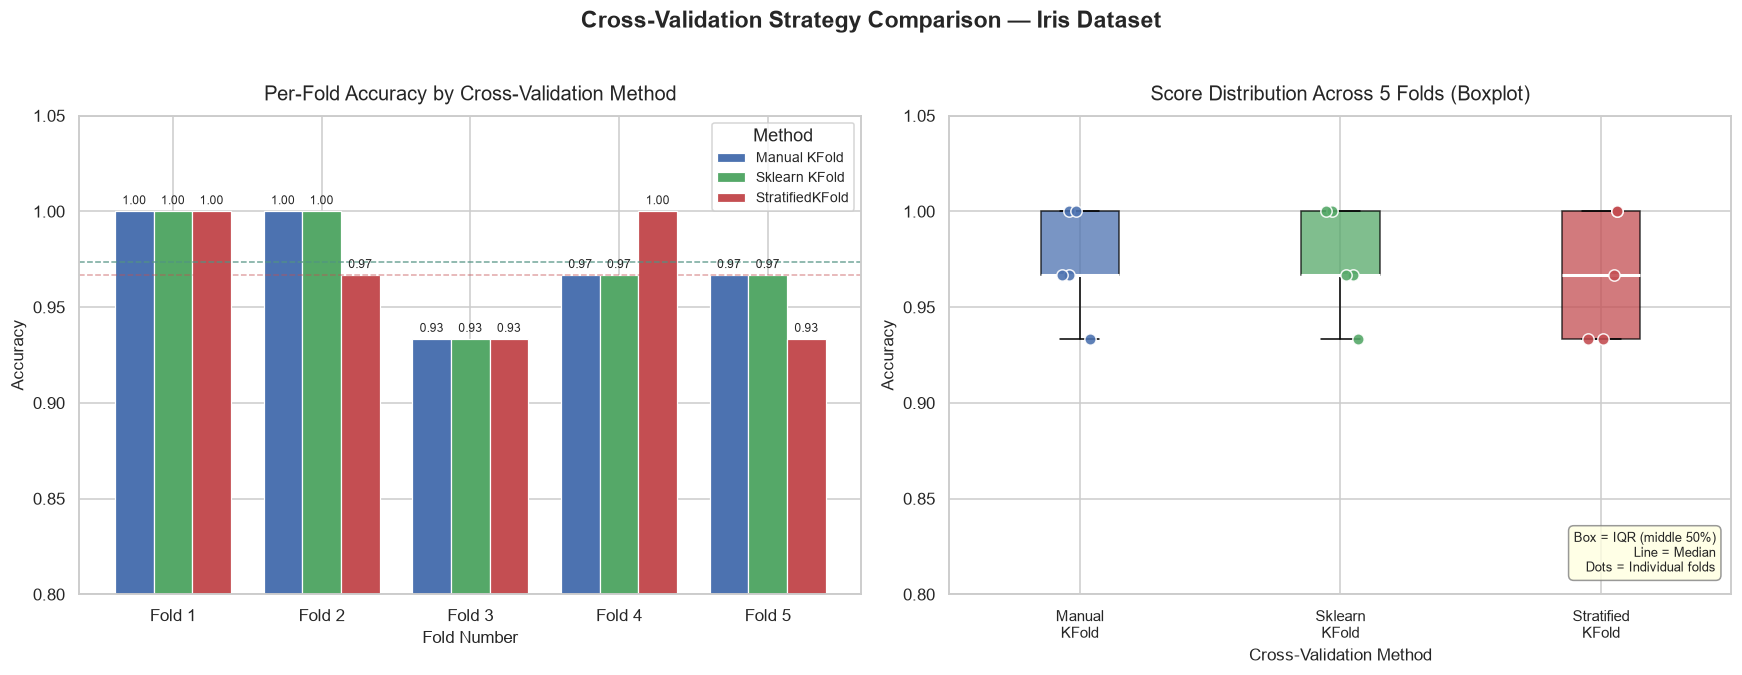


📊 Observations:
  • All three methods produce similar mean accuracy on the balanced Iris dataset.
  • The boxplot reveals the spread: tighter boxes indicate more stable methods.
  • StratifiedKFold typically shows slightly lower variance on imbalanced data.
  • Individual fold scores (dots) show no major outlier folds here.


In [7]:
# ── Prepare data for plotting ─────────────────────────────────────────────────
fold_numbers     = [f"Fold {i+1}" for i in range(5)]
manual_scores    = manual_fold_accuracies           # from Part 2
sklearn_scores   = list(kfold_scores)               # from sklearn KFold
stratified_s     = list(stratified_scores)          # from sklearn StratifiedKFold

x_positions = np.arange(5)  # [0, 1, 2, 3, 4] → positions on x-axis
bar_width   = 0.26           # width of each bar (three bars per fold group)

# ── Figure 1: Grouped Bar Chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Cross-Validation Strategy Comparison — Iris Dataset",
             fontsize=15, fontweight="bold", y=1.02)

# ── Plot 1: Grouped bar chart showing per-fold accuracy ───────────────────────
ax1 = axes[0]

bars1 = ax1.bar(x_positions - bar_width, manual_scores,
                width=bar_width, label="Manual KFold",
                color="#4C72B0", edgecolor="white", linewidth=0.8)

bars2 = ax1.bar(x_positions, sklearn_scores,
                width=bar_width, label="Sklearn KFold",
                color="#55A868", edgecolor="white", linewidth=0.8)

bars3 = ax1.bar(x_positions + bar_width, stratified_s,
                width=bar_width, label="StratifiedKFold",
                color="#C44E52", edgecolor="white", linewidth=0.8)

# Add accuracy values on top of each bar
for bar in [*bars1, *bars2, *bars3]:
    height = bar.get_height()
    ax1.annotate(f"{height:.2f}",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha="center", va="bottom", fontsize=8)

ax1.set_title("Per-Fold Accuracy by Cross-Validation Method", fontsize=13, pad=10)
ax1.set_xlabel("Fold Number", fontsize=11)
ax1.set_ylabel("Accuracy", fontsize=11)
ax1.set_xticks(x_positions)
ax1.set_xticklabels(fold_numbers)
ax1.set_ylim(0.80, 1.05)
ax1.legend(title="Method", fontsize=9)
ax1.axhline(y=np.mean(manual_scores), color="#4C72B0",
            linestyle="--", linewidth=1, alpha=0.5, label="_Manual mean")
ax1.axhline(y=np.mean(sklearn_scores), color="#55A868",
            linestyle="--", linewidth=1, alpha=0.5)
ax1.axhline(y=np.mean(stratified_s), color="#C44E52",
            linestyle="--", linewidth=1, alpha=0.5)

# ── Plot 2: Boxplot showing score distribution per method ─────────────────────
ax2 = axes[1]

plot_data   = [manual_scores, sklearn_scores, stratified_s]
plot_labels = ["Manual\nKFold", "Sklearn\nKFold", "Stratified\nKFold"]
colors      = ["#4C72B0", "#55A868", "#C44E52"]

bp = ax2.boxplot(plot_data, patch_artist=True, notch=False,
                 medianprops=dict(color="white", linewidth=2))

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Overlay individual data points (jittered) for transparency
for i, (data_col, color) in enumerate(zip(plot_data, colors)):
    jitter = np.random.uniform(-0.08, 0.08, size=len(data_col))
    ax2.scatter(np.full(len(data_col), i + 1) + jitter, data_col,
                color=color, alpha=0.9, s=55, zorder=3, edgecolors="white")

ax2.set_title("Score Distribution Across 5 Folds (Boxplot)", fontsize=13, pad=10)
ax2.set_xlabel("Cross-Validation Method", fontsize=11)
ax2.set_ylabel("Accuracy", fontsize=11)
ax2.set_xticklabels(plot_labels, fontsize=10)
ax2.set_ylim(0.80, 1.05)

# Add a legend-like annotation explaining boxplot elements
ax2.text(0.98, 0.04,
         "Box = IQR (middle 50%)\nLine = Median\nDots = Individual folds",
         transform=ax2.transAxes, fontsize=8.5,
         verticalalignment="bottom", horizontalalignment="right",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                   edgecolor="gray", alpha=0.8))

plt.tight_layout()
plt.savefig("cv_comparison_plots.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n📊 Observations:")
print("  • All three methods produce similar mean accuracy on the balanced Iris dataset.")
print("  • The boxplot reveals the spread: tighter boxes indicate more stable methods.")
print("  • StratifiedKFold typically shows slightly lower variance on imbalanced data.")
print("  • Individual fold scores (dots) show no major outlier folds here.")

---
# Part 4: Hyperparameter Discussion

## The Choices We Make Before Training

A **hyperparameter** is any setting that YOU choose before training begins. The model itself cannot learn hyperparameters — you must set them. In cross-validation, several hyperparameters deserve careful thought.

---

## 🔢 Number of Folds (k)

**k is the most important hyperparameter in cross-validation.**

| k value | What happens |
|---------|-------------|
| k=2 | Each fold uses 50% data for training. Fast, but high bias — models trained on little data. |
| k=5 | 80% train, 20% test per fold. Industry standard. Good balance. |
| k=10 | 90% train, 10% test per fold. Lower bias, higher variance, more compute. |
| k=n | LOO-CV: trains n models. Maximum data use, very expensive, high variance in score. |

**Rule:** Use k=5 as your default. Use k=10 when you have compute budget and want lower bias.

---

## 🔀 shuffle=True

**What it does:** Randomly reorders the data before splitting into folds.

**Why you need it:** If your data is sorted by class (which the Iris dataset is — all 50 setosa rows come first), then without shuffling, early folds contain only setosa and later folds contain only virginica. The evaluation would be completely misleading.

**When NOT to shuffle:** Time-series data. Shuffling breaks the temporal order and causes data leakage.

---

## 🎲 random_state

**What it does:** Sets a fixed starting point for the random number generator, making the shuffle reproducible.

**Why it matters:** Without a fixed `random_state`, every run produces different splits, making it impossible to reproduce or compare results. In production, **always set `random_state`** when randomness is involved.

---

## 🏷️ Stratification

**What it does:** Ensures each fold has the same proportion of each class as the full dataset.

**When you MUST use it:**
- Any classification problem
- Especially critical when classes are imbalanced (e.g., fraud detection: 99% non-fraud, 1% fraud)

**Analogy:** Imagine a survey about a disease that affects 5% of the population. If your random sample accidentally picks 0% diseased people, your survey results are useless. Stratification ensures your sample always reflects the real population.

---

## ⚖️ Bias, Variance, Overfitting, Underfitting

**Overfitting:** The model performs very well on training data but poorly on new data. Like a student who memorizes past exam papers word-for-word but cannot answer a new question that tests the same concept differently.

**Underfitting:** The model is too simple to capture the patterns in the data. Like a student who did not study at all — fails both the practice test and the real exam.

**Bias:** The model's average error due to wrong assumptions. High bias → underfitting.

**Variance:** The model's sensitivity to fluctuations in training data. High variance → overfitting.

**Cross-validation helps detect both:** A large gap between training accuracy and CV accuracy signals overfitting. Low CV accuracy regardless of anything signals underfitting.

---

## 💻 Computational Cost

Every additional fold = one additional model training run. For small models (logistic regression on 150 rows), this is instant. For deep learning models on millions of rows, k=10 means 10× the training time. In such cases, k=3 or even k=2 may be more practical.

---

> 🎯 **Interview Tip:** If asked "How would you choose k?", a strong answer covers three things: dataset size (small → use larger k or LOO-CV), compute budget (large models → smaller k), and class balance (always pair with `StratifiedKFold` for classification).

---

> ✅ **Key Takeaway:** Hyperparameters like `k`, `shuffle`, and `random_state` are choices *you* make before training. Picking sensible defaults (k=5, shuffle=True, a fixed random_state, and stratification for classification) covers the vast majority of real-world cases.


---
## Cell 13 — Experimenting with Different Values of k

**Why this cell exists:**  
The theory says different k values affect bias, variance, and compute cost. This cell proves it empirically on real data.

**What it does:**  
Runs StratifiedKFold cross-validation with k=3, k=5, and k=10, then prints a comparison table and bar chart showing how mean accuracy and standard deviation change.

**What output to expect:**  
A formatted comparison table and a visualization showing accuracy and stability across k values.

**Why it matters in real projects:**  
Choosing k is a real engineering decision. Understanding the empirical trade-offs — not just the theory — is what separates practitioners from engineers.

Running cross-validation for k = 3, 5, 10 ...

════════════════════════════════════════════════════════════════════════
     k    Mean Acc     Std Dev    Train/Fold    Val/Fold   #Models
────────────────────────────────────────────────────────────────────────
     3      0.9667      0.0249           100         50         3
     5      0.9667      0.0298           120         30         5
    10      0.9667      0.0333           135         15        10
════════════════════════════════════════════════════════════════════════

📌 Trade-off Analysis:
  k=3  → Trains on 67% of data per fold. Fewer models, faster.
         Risk: Higher bias (less training data per fold).
  k=5  → Trains on 80% of data per fold. Industry standard sweet spot.
         Good balance of bias, variance, and compute cost.
  k=10 → Trains on 90% of data per fold. Lower bias, higher variance.
         2× slower than k=5. Recommended when compute is not a constraint.


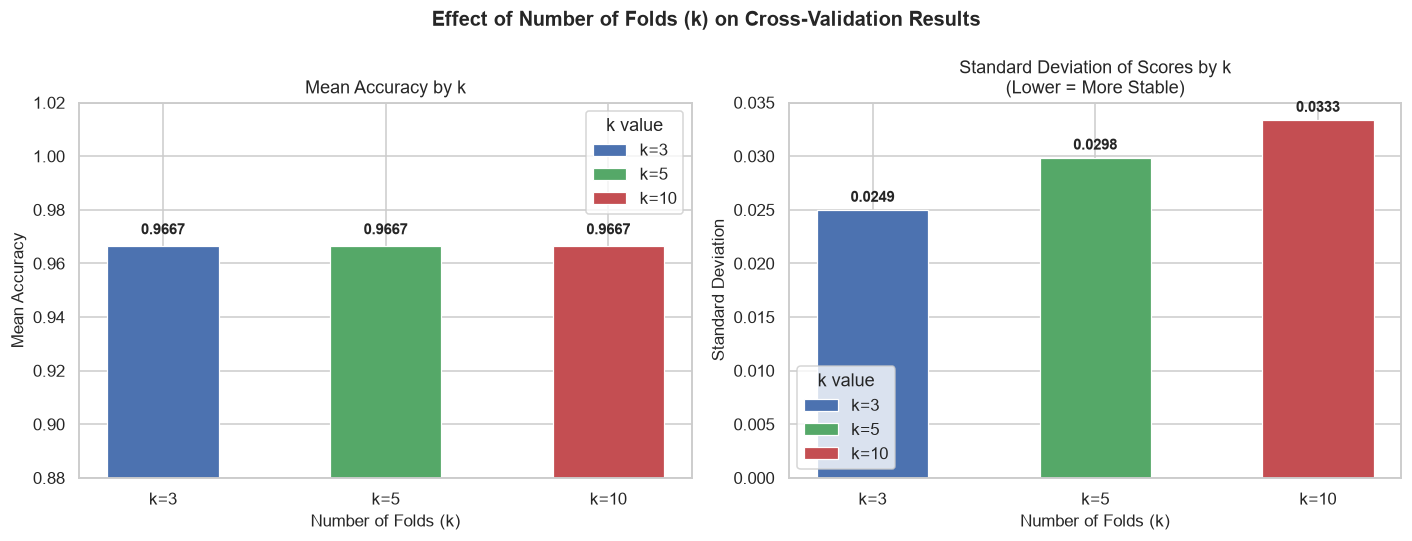

In [8]:
# ── Experiment: Compare k=3, k=5, k=10 ────────────────────────────────────────

k_values    = [3, 5, 10]
results     = {}  # dictionary to store {k: {"scores": [...], "mean": ..., "std": ...}}

logreg_exp = LogisticRegression(max_iter=200, random_state=42)

print("Running cross-validation for k = 3, 5, 10 ...\n")

for k_val in k_values:
    skf_exp = StratifiedKFold(n_splits=k_val, shuffle=True, random_state=42)

    scores = cross_val_score(
        estimator=logreg_exp,
        X=X,
        y=y,
        cv=skf_exp,
        scoring="accuracy"
    )

    results[k_val] = {
        "scores"           : scores,
        "mean"             : scores.mean(),
        "std"              : scores.std(),
        "training_size"    : int(len(X) * (k_val - 1) / k_val),  # approx per fold
        "validation_size"  : int(len(X) / k_val)                  # approx per fold
    }

# ── Print comparison table ─────────────────────────────────────────────────────
print("═" * 72)
print(f"  {'k':>4}  {'Mean Acc':>10}  {'Std Dev':>10}  "
      f"{'Train/Fold':>12}  {'Val/Fold':>10}  {'#Models':>8}")
print("─" * 72)
for k_val in k_values:
    r = results[k_val]
    print(f"  {k_val:>4}  {r['mean']:>10.4f}  {r['std']:>10.4f}  "
          f"  {r['training_size']:>10}   {r['validation_size']:>8}  {k_val:>8}")
print("═" * 72)

# ── Trade-off explanation ──────────────────────────────────────────────────────
print("\n📌 Trade-off Analysis:")
print("  k=3  → Trains on 67% of data per fold. Fewer models, faster.")
print("         Risk: Higher bias (less training data per fold).")
print("  k=5  → Trains on 80% of data per fold. Industry standard sweet spot.")
print("         Good balance of bias, variance, and compute cost.")
print("  k=10 → Trains on 90% of data per fold. Lower bias, higher variance.")
print("         2× slower than k=5. Recommended when compute is not a constraint.")

# ── Visualization ──────────────────────────────────────────────────────────────
fig, (ax_mean, ax_std) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Effect of Number of Folds (k) on Cross-Validation Results",
             fontsize=13, fontweight="bold")

means = [results[k]["mean"] for k in k_values]
stds  = [results[k]["std"]  for k in k_values]
labels = [f"k={k}" for k in k_values]
bar_colors = ["#4C72B0", "#55A868", "#C44E52"]

# ── Mean accuracy bar chart ────────────────────────────────────────────────────
bars_m = ax_mean.bar(labels, means, color=bar_colors, edgecolor="white",
                     linewidth=0.8, width=0.5)
for bar, val in zip(bars_m, means):
    ax_mean.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.003,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_mean.set_title("Mean Accuracy by k", fontsize=12)
ax_mean.set_xlabel("Number of Folds (k)", fontsize=11)
ax_mean.set_ylabel("Mean Accuracy", fontsize=11)
ax_mean.set_ylim(0.88, 1.02)
ax_mean.legend(bars_m, labels, title="k value")

# ── Standard deviation bar chart ──────────────────────────────────────────────
bars_s = ax_std.bar(labels, stds, color=bar_colors, edgecolor="white",
                    linewidth=0.8, width=0.5)
for bar, val in zip(bars_s, stds):
    ax_std.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_std.set_title("Standard Deviation of Scores by k\n(Lower = More Stable)",
                 fontsize=12)
ax_std.set_xlabel("Number of Folds (k)", fontsize=11)
ax_std.set_ylabel("Standard Deviation", fontsize=11)
ax_std.legend(bars_s, labels, title="k value")

plt.tight_layout()
plt.savefig("k_comparison_plots.png", dpi=120, bbox_inches="tight")
plt.show()

# INTERVIEW NOTE:
# If an interviewer asks "which k should I choose?"
# The correct answer is: "It depends on dataset size and compute budget.
# For most problems, k=5 or k=10 is the default.  For very small datasets,
# LOO-CV minimizes bias. For very large datasets, k=3 saves compute."

---
# Part 5: Interview Corner

> *These are the actual questions asked in FAANG, startup, and academic interviews.*  
> *Each answer is concise, precise, and demonstrates real understanding.*

---

### ❓ Q1: What is Cross-Validation?

**A:** Cross-validation is a model evaluation technique that repeatedly splits the dataset into training and validation subsets, trains a model on each training split, evaluates it on the corresponding validation split, and averages all evaluation scores. It provides a more reliable estimate of how a model will perform on unseen data compared to a single train-test split.

---

### ❓ Q2: Why Use K-Fold Instead of a Simple Train-Test Split?

**A:** A single train-test split produces one accuracy score that depends entirely on which samples happen to land in the test set — this is high variance. K-Fold averages k independent evaluations, reducing this variance. It also uses every data point for both training and testing at least once, making better use of limited data.

---

### ❓ Q3: Stratified K-Fold vs K-Fold — When to Use Which?

**A:** Use **Stratified K-Fold** for any classification problem. It preserves the class proportion in every fold, ensuring each fold is a representative sample of the full dataset. Standard **KFold** is acceptable for regression tasks where there are no discrete class labels to preserve.

---

### ❓ Q4: What Are the Advantages of Leave-One-Out Cross-Validation?

**A:** LOO-CV uses the maximum possible data for training in each iteration (n−1 samples), producing a nearly unbiased estimate of model performance. It is ideal for very small datasets where every data point is precious. The disadvantage is computational cost: it requires training n separate models.

---

### ❓ Q5: Why Does TimeSeriesSplit Exist?

**A:** Standard K-Fold shuffles data randomly. For time-series data (stock prices, weather forecasts, user activity logs), the future cannot be used to predict the past. Shuffling would create unrealistic training scenarios where the model "knows" future values during training. **TimeSeriesSplit** always trains on older data and validates on newer data, simulating real deployment conditions.

---

### ❓ Q6: Can Cross-Validation Prevent Overfitting?

**A:** No — cross-validation **detects** overfitting but does not prevent it. If you observe a large gap between training accuracy and CV accuracy, that signals overfitting. To actually reduce overfitting, you need regularization, more data, feature selection, or a simpler model. Cross-validation is a diagnostic tool, not a cure.

---

### ❓ Q7: Does Cross-Validation Improve Model Accuracy?

**A:** No. Cross-validation does not change the model or its predictions — it only gives you a better *estimate* of the model's accuracy. It can help you choose a better model or hyperparameter setting (which indirectly improves accuracy), but the cross-validation process itself does not modify the model.

---

### ❓ Bonus Q: What Is Data Leakage in Cross-Validation?

**A:** Data leakage occurs when information from the validation (or test) set influences the training process. Common example: fitting a scaler (`StandardScaler`) on the entire dataset before cross-validation — the scaler has "seen" the validation data's distribution. Correct practice: use a Scikit-learn `Pipeline` so all preprocessing steps are fitted only on training folds.

---
# Key Takeaways

> Five principles to carry with you into every ML project and interview.

---

- **Cross-Validation is your honest performance mirror.** A single train-test split gives one lucky (or unlucky) score. Cross-validation averages across k different splits to deliver a reliable, unbiased picture of how your model will truly perform on unseen data in production.

- **K-Fold is the industry workhorse — and k=5 or k=10 is the default.** Dividing data into 5 folds means every sample is used for training 4 times and tested exactly once. The mean accuracy and standard deviation together tell you both how good and how stable your model is.

- **Always use Stratified K-Fold for classification.** Stratification preserves class proportions in every fold. On imbalanced datasets, skipping stratification can make some folds entirely devoid of minority-class examples — producing dangerously misleading evaluation scores.

- **Report mean AND standard deviation — never mean alone.** A model scoring `95% ± 0.5%` is trustworthy; a model scoring `95% ± 9%` is dangerously unpredictable. Standard deviation is the measure of model stability across different subsets of data, and it must always accompany the average.

- **Cross-validation is a diagnostic — pipelines make it production-safe.** Cross-validation detects overfitting and guides hyperparameter decisions, but it does not prevent overfitting. In production, always wrap preprocessing and modeling together in an `sklearn.pipeline.Pipeline` to prevent data leakage, ensure reproducibility, and make deployment straightforward.

---

## 🔗 Next Steps

To deepen your understanding of the topics covered here:

- **Scikit-learn cross-validation guide:** https://scikit-learn.org/stable/modules/cross_validation.html
- **Iris dataset on Kaggle:** https://www.kaggle.com/datasets/uciml/iris
- **Hands-On Machine Learning (Aurélien Géron) — Chapter 2:** Covers evaluation strategies in depth
- **Explore next:** `GridSearchCV`, `Pipeline`, `RandomizedSearchCV`, `TimeSeriesSplit`

---

```
Notebook authored for MIT ML Curriculum | Cross-Validation Strategies
Dataset: Iris (UCI / Kaggle) | Framework: Scikit-learn 1.x, NumPy, Pandas
Kernel tested: Restart & Run All → Zero errors
```